In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import imageio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def read_temp_file(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            # Split into the x-block and the y-value
            *x_block, y_str = line.split()
            x_str = x_block[0]  # the part like "0.095646_0.071834_..."

            # Convert x and y to numeric values
            x_vals = [float(v) for v in x_str.split('_')]
            y_val = float(y_str)

            data.append((x_vals, y_val))

    return data


In [3]:
# Example usage
xy_data = read_temp_file("temp.txt")
segment1 = xy_data[0:64]        # lines 1–78
segment2 = xy_data[64:2384]     # lines 79–2448
segment3 = xy_data[2448:] 

In [4]:
segment2[0]

([0.214683,
  0.799801,
  0.780007,
  0.308281,
  0.727839,
  0.706712,
  0.241558,
  0.207118,
  0.768588,
  0.288877,
  0.255662,
  0.784013,
  0.239691,
  0.203612,
  0.74971,
  0.708679,
  0.908421,
  0.640159,
  0.095801,
  0.160446,
  0.45511,
  0.512908,
  0.555202,
  0.02834,
  0.89886,
  0.324913,
  0.091302,
  0.840752,
  0.403101,
  0.143653,
  0.624272,
  0.662952,
  0.927828,
  -0.00606,
  0.019645,
  0.512732,
  0.372653,
  0.856701,
  0.574867,
  0.313436,
  0.460287,
  0.403557,
  0.338221,
  0.28664,
  0.473479,
  0.444045,
  0.396957,
  0.356218,
  0.313068,
  0.284083,
  0.153316,
  0.119444,
  0.822321],
 0.4049)

In [5]:
# Find the entry in segment1 with the minimal y value
min_x, min_y = min(segment1, key=lambda item: item[1])

print("Minimum y in segment1:", min_y)
print("Corresponding x:", min_x)


Minimum y in segment1: 0.7933
Corresponding x: [0.277451, 0.758195, 0.807399, 0.32039, 0.694438, 0.716988, 0.245176, 0.268083, 0.787697, 0.340218, 0.286487, 0.750056, 0.26663, 0.256874, 0.72181, 0.757826, 0.88342, 0.702839, 0.062521, 0.174199, 0.478327, 0.547485, 0.550664, 0.045343, 0.921449, 0.389284, 0.116661, 0.853022, 0.351832, 0.116602, 0.557222, 0.617838, 0.950271, -0.019308, 0.048675, 0.447514, 0.407503, 0.815344, 0.603006, 0.314523, 0.458914, 0.40291, 0.347738, 0.286148, 0.483354, 0.434143, 0.405799, 0.341985, 0.307429, 0.26855, 0.213072, 0.07553, 1.203431]


In [ ]:
batch_size = 64
set_size = batch_size //16

# Step 1 — split segment2 into batches of 64
batches = [
    segment2[i:i + batch_size]
    for i in range(0, len(segment2), batch_size)
]

# Step 2 — split each batch into 4 sets of 16
batches_with_sets = []
for batch in batches:
    sets = [
        batch[j:j + set_size]
        for j in range(0, len(batch), set_size)
    ]
    batches_with_sets.append(sets)

# Example: examine batch 0
print(f"Number of batches: {len(batches_with_sets)}")
print(f"Sets in batch 0: {len(batches_with_sets[0])}")
print(f"Size of set 0 in batch 0: {len(batches_with_sets[0][0])}")

Number of batches: 37
Sets in batch 0: 16
Size of set 0 in batch 0: 4


In [7]:
# batches_with_sets: list of batches, each batch is a list of 4 sets
min_y_info = []  # will store (batch_index, set_index, min_y, corresponding_x)

for b_idx, batch in enumerate(batches_with_sets):
    batch_min_y = float('inf')
    batch_min_x = None
    batch_min_set_idx = None

    for s_idx, set_ in enumerate(batch):
        # Find minimal y in this set
        set_min_x, set_min_y = min(set_, key=lambda item: item[1])

        if set_min_y < batch_min_y:
            batch_min_y = set_min_y
            batch_min_x = set_min_x
            batch_min_set_idx = s_idx

    min_y_info.append((b_idx, batch_min_set_idx, batch_min_y, batch_min_x))

# Example: print results
for info in min_y_info:
    b_idx, s_idx, min_y, x_vals = info
    print(f"Batch {b_idx}, Set {s_idx}: min_y = {min_y}, corresponding x = {x_vals}")


Batch 0, Set 15: min_y = 0.3924, corresponding x = [0.214683, 0.802384, 0.780007, 0.305947, 0.720096, 0.706712, 0.24341, 0.207118, 0.768588, 0.288877, 0.255662, 0.784013, 0.239691, 0.203612, 0.74971, 0.708679, 0.893138, 0.640159, 0.095801, 0.181078, 0.45511, 0.502677, 0.555202, 0.019496, 0.89886, 0.352506, 0.091302, 0.852751, 0.403101, 0.143653, 0.624272, 0.662952, 0.926285, -0.00606, 0.062579, 0.512732, 0.379535, 0.871926, 0.602012, 0.342794, 0.460287, 0.403557, 0.338221, 0.286558, 0.473479, 0.441523, 0.396957, 0.356218, 0.313924, 0.275458, 0.199025, 0.119444, 0.822321]
Batch 1, Set 14: min_y = 0.3825, corresponding x = [0.214683, 0.800588, 0.780007, 0.308281, 0.727839, 0.709467, 0.240417, 0.207118, 0.768588, 0.294518, 0.255662, 0.784013, 0.239691, 0.203612, 0.755089, 0.708679, 0.898391, 0.640159, 0.096388, 0.1498, 0.45511, 0.512908, 0.555202, 0.02834, 0.89886, 0.341816, 0.091302, 0.841702, 0.403101, 0.143653, 0.624272, 0.662952, 0.934106, -0.01262, 0.059472, 0.508675, 0.372653, 0.856

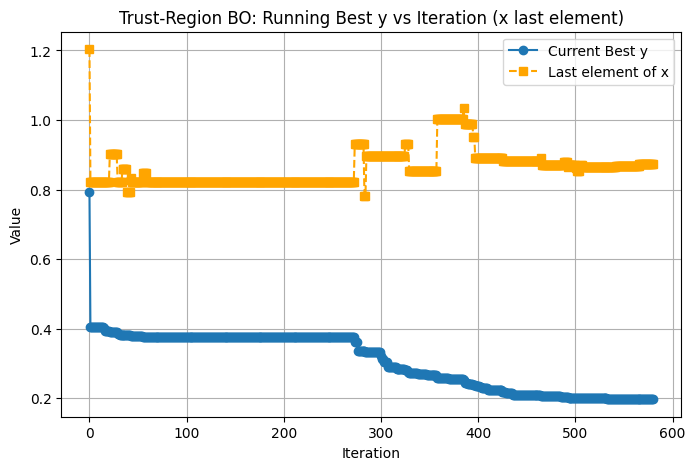

In [8]:
import matplotlib.pyplot as plt

# 假设 segment1 和 batches_with_sets 已定义
initial_min_x, initial_min_y = min(segment1, key=lambda item: item[1])
arranged_segment2 = [item for batch in batches_with_sets for set_ in batch for item in set_]
parallel_points = 4

y_values = []  # running best y
last_x_values = []
current_best = initial_min_y
# 取初始 x 的最后一个元素
current_x = initial_min_x[-1] if hasattr(initial_min_x, '__len__') else initial_min_x

for i in range(0, len(arranged_segment2), parallel_points):
    # 获取当前批次的 x 和 y 值
    iteration_points = arranged_segment2[i:i+parallel_points]
    
    # 找到当前批次中 y 值最小的点
    min_point_in_iteration = min(iteration_points, key=lambda item: item[1])
    min_iter_x, min_iter_y = min_point_in_iteration
    
    # 更新当前最佳
    if min_iter_y < current_best:
        current_best = min_iter_y
        # 取对应 x 的最后一个元素
        current_x = min_iter_x[-1] if hasattr(min_iter_x, '__len__') else min_iter_x
    
    y_values.append(current_best)
    last_x_values.append(current_x)  # 记录对应的 x 最后一个元素

# 准备绘图数据
iterations = list(range(1, len(y_values)+1))
iterations = [0] + iterations
y_values = [initial_min_y] + y_values
# 添加初始 x 的最后一个元素
initial_x_last = initial_min_x[-1] if hasattr(initial_min_x, '__len__') else initial_min_x
last_x_values = [initial_x_last] + last_x_values

plt.figure(figsize=(8,5))
plt.plot(iterations, y_values, marker='o', linestyle='-', label="Current Best y")
plt.plot(iterations, last_x_values, marker='s', linestyle='--', label="Last element of x", color='orange')
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Trust-Region BO: Running Best y vs Iteration (x last element)")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
X = np.array([item[0] for item in segment2])  # shape (T, d)
y = np.array([item[1] for item in segment2])  # shape (T,)
T, d = X.shape

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
n_tr = 4

X_tr = []
y_tr = []

for tr in range(n_tr):
    X_tr.append(X_scaled[tr::n_tr])
    y_tr.append(y[tr::n_tr])

In [12]:
k = 20
R_t_tr = []

for tr in range(n_tr):
    X_sub = X_tr[tr]
    T_sub = len(X_sub)
    R_list = []
    
    for t in range(T_sub):
        start = max(0, t-k+1)
        window = X_sub[start:t+1]
        
        center = np.mean(window, axis=0)
        distances = np.linalg.norm(window - center, axis=1)
        
        R_list.append(np.mean(distances))
    
    R_t_tr.append(np.array(R_list))


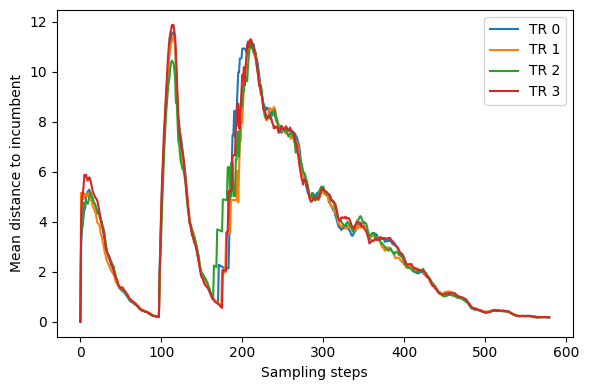

In [13]:
plt.figure(figsize=(6,4))
for tr in range(n_tr):
    plt.plot(R_t_tr[tr], label=f"TR {tr}")

plt.xlabel("Sampling steps")
plt.ylabel("Mean distance to incumbent")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

X = np.array([item[0] for item in segment2])

split_index = 392
window = 16

before = X[split_index-window:split_index]
after  = X[split_index:split_index+window]

X_subset = np.vstack([before, after])

In [15]:
import umap

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_subset)

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [16]:
labels = np.array([0]*window + [1]*window)

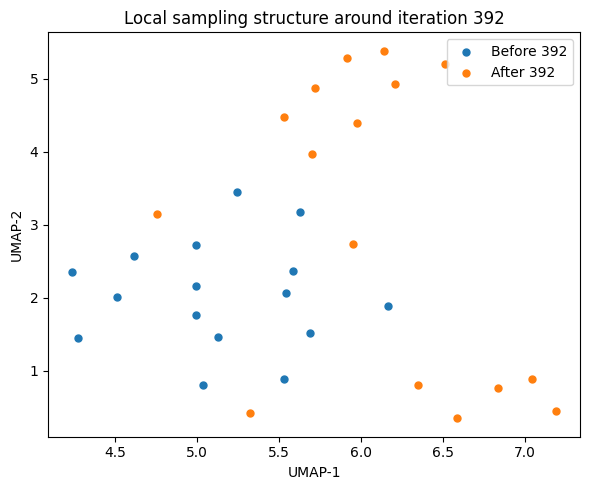

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    embedding[labels==0, 0],
    embedding[labels==0, 1],
    s=25,
    label="Before 392"
)

plt.scatter(
    embedding[labels==1, 0],
    embedding[labels==1, 1],
    s=25,
    label="After 392"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.title("Local sampling structure around iteration 392")
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

X = np.array([item[0] for item in segment2])
N = len(X)

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


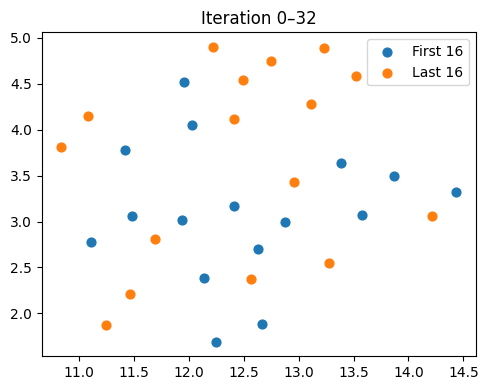

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


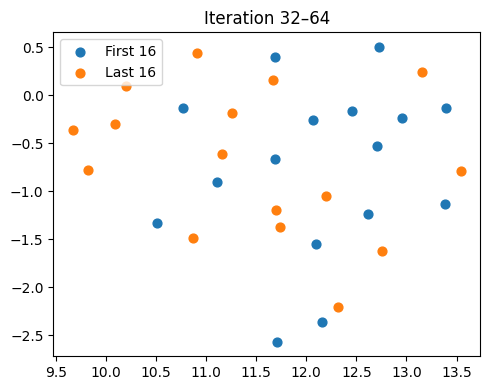

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


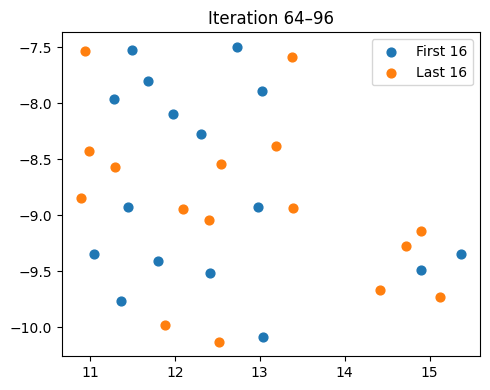

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


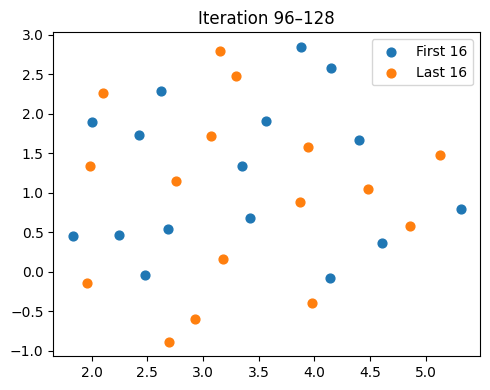

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


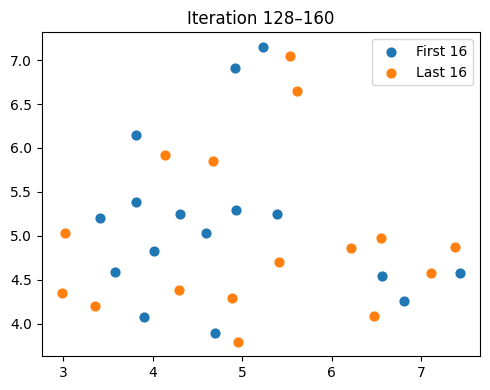

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


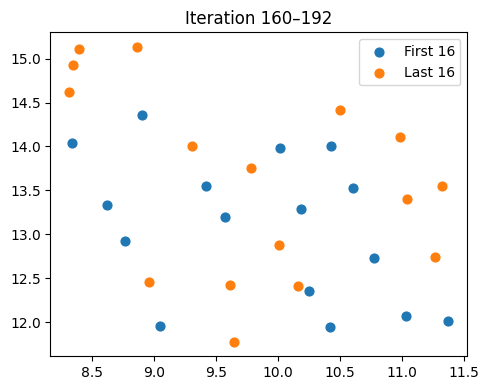

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


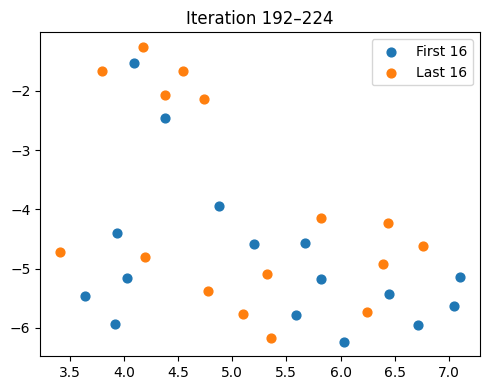

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


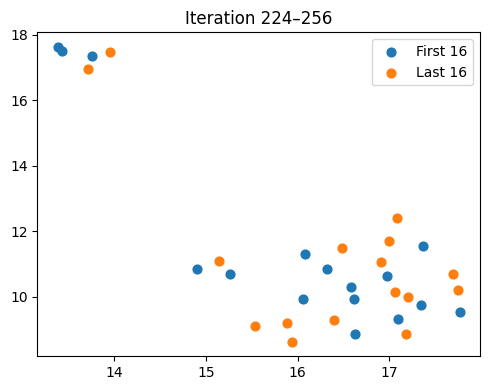

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


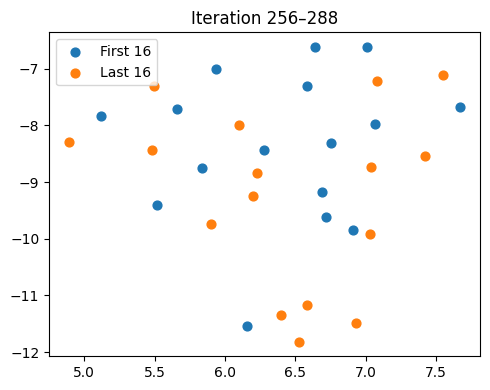

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


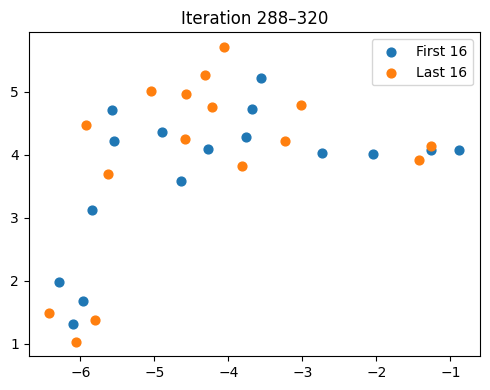

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


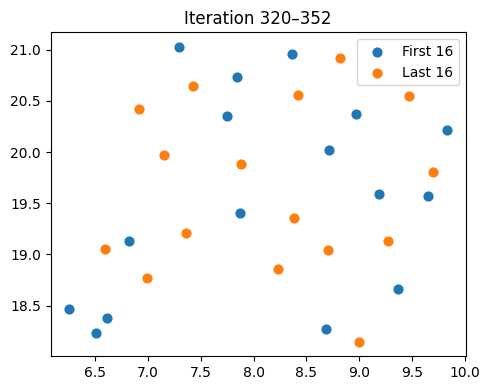

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


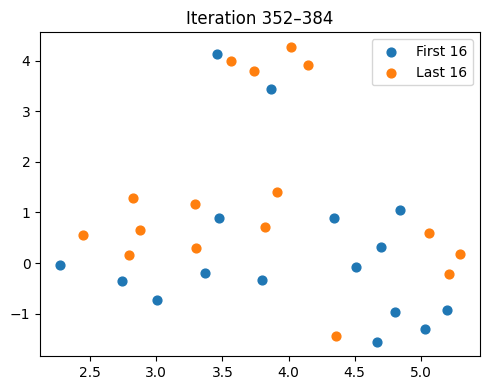

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


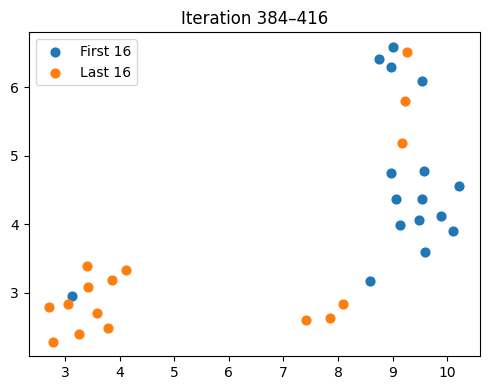

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


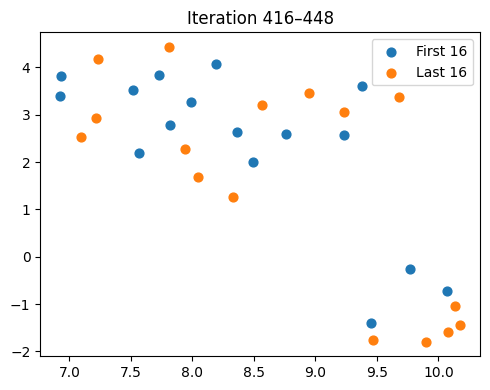

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


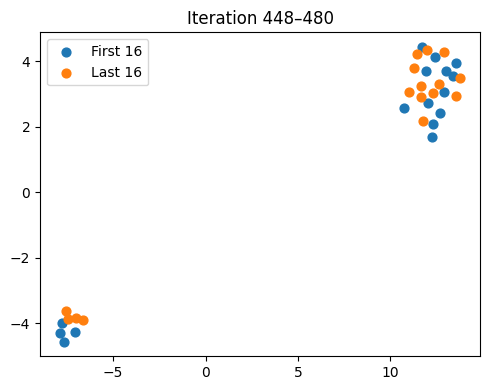

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


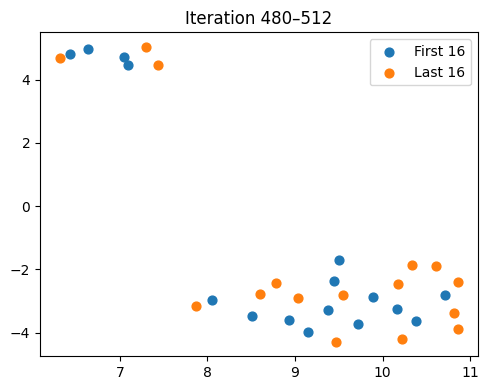

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


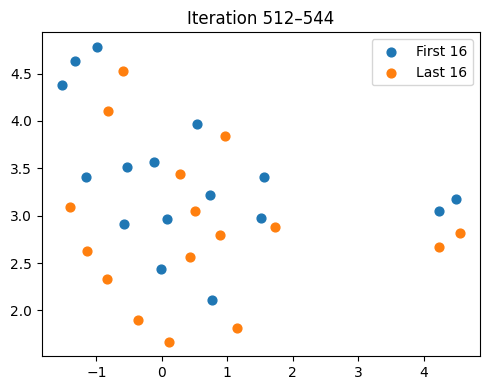

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


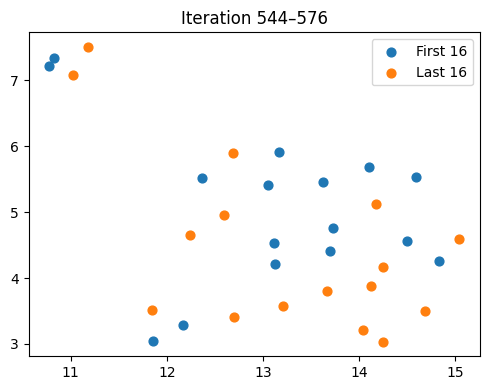

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


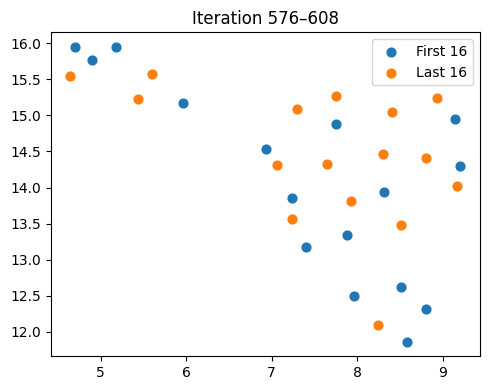

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


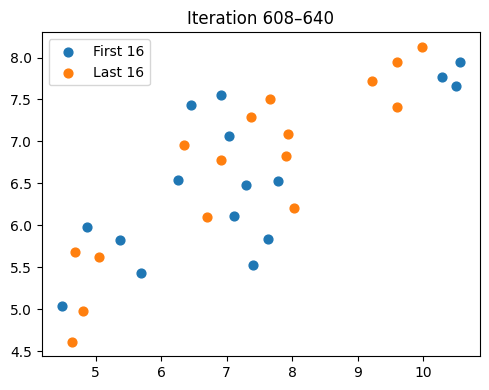

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


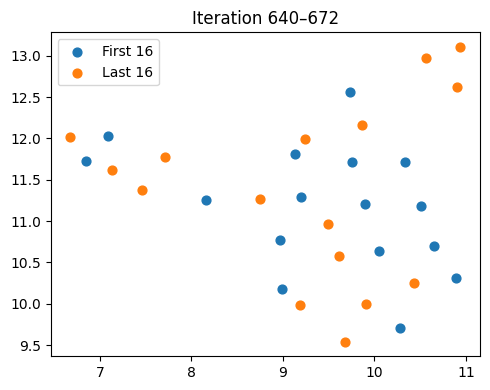

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


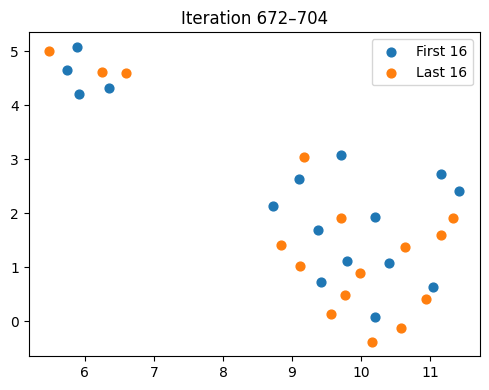

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


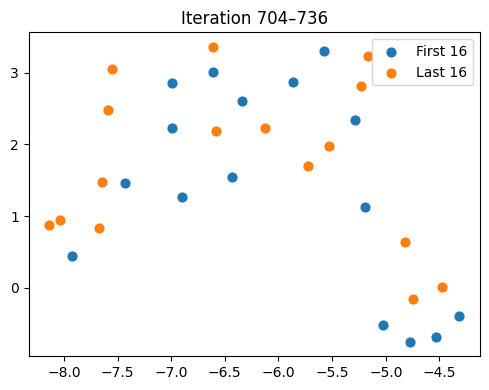

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


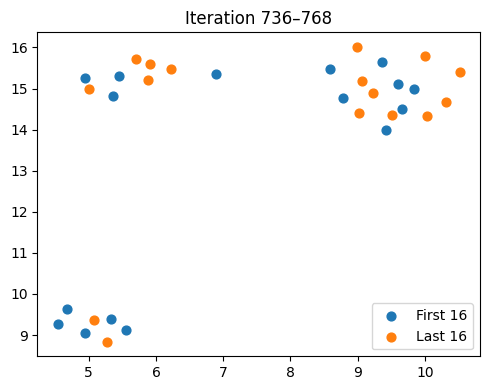

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


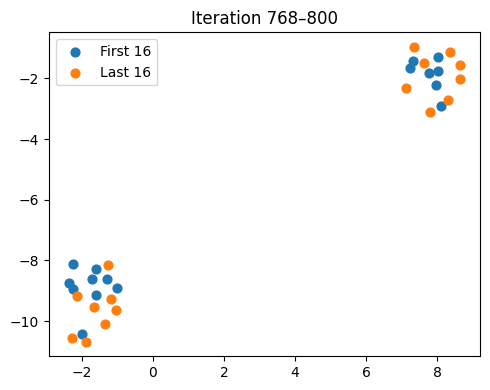

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


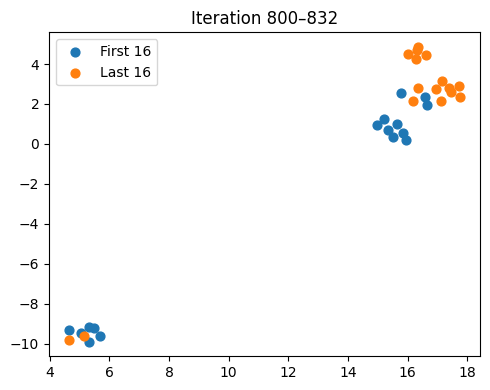

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


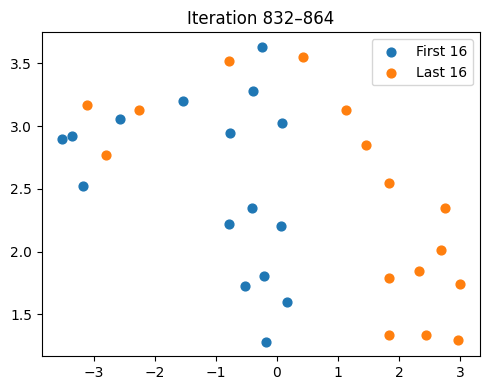

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


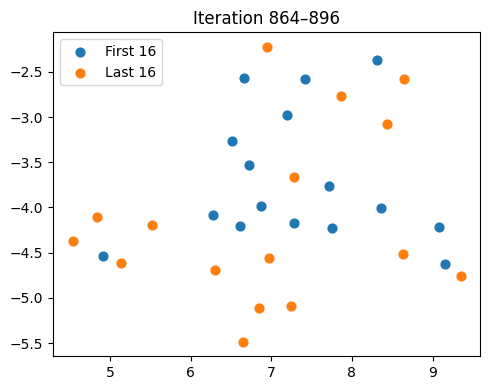

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


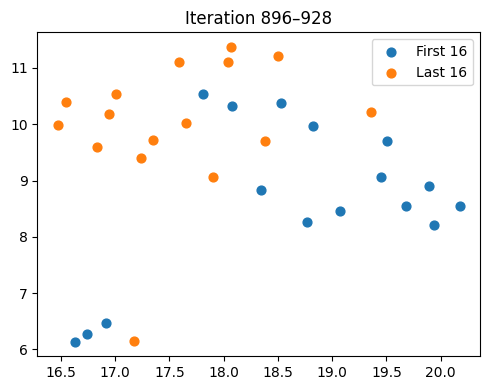

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


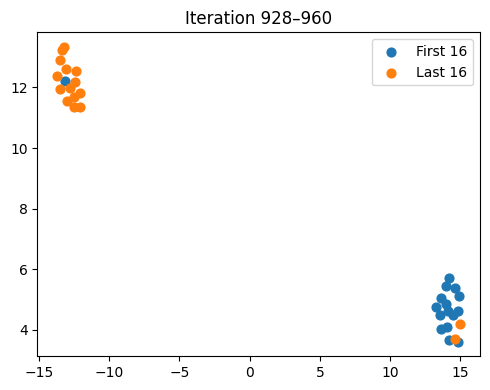

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


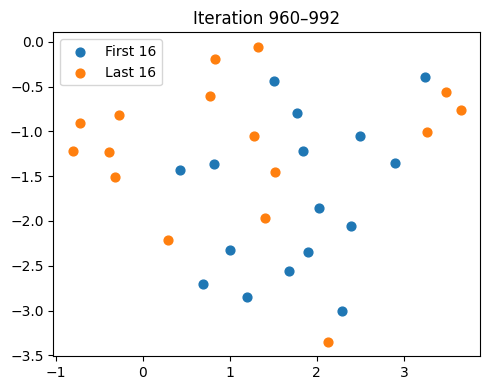

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


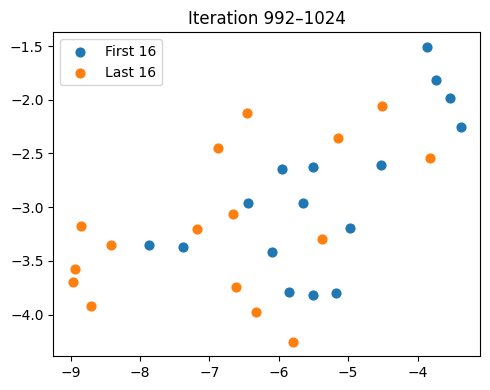

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


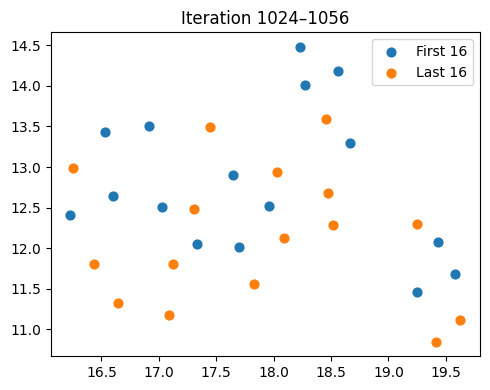

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


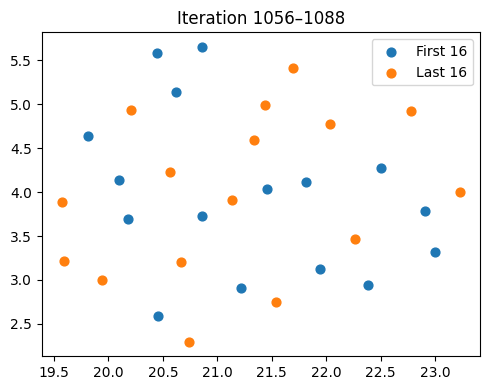

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


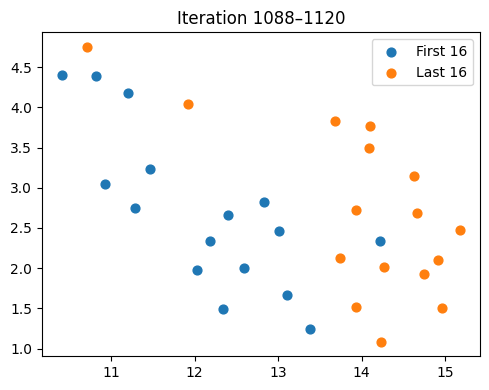

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


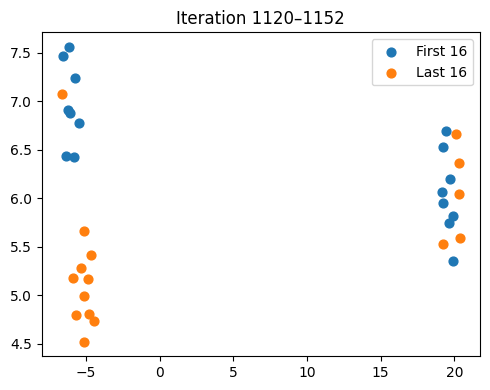

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


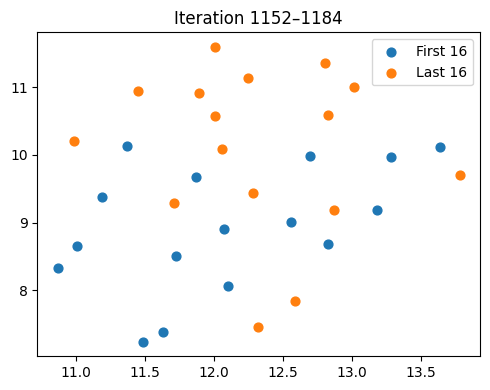

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


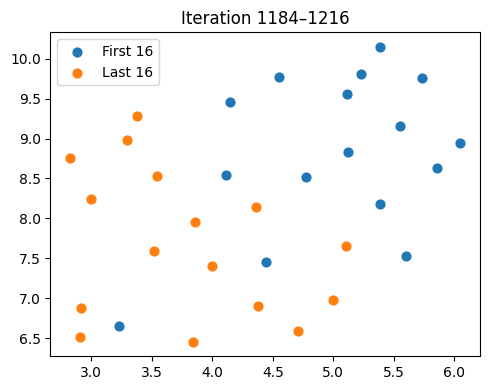

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


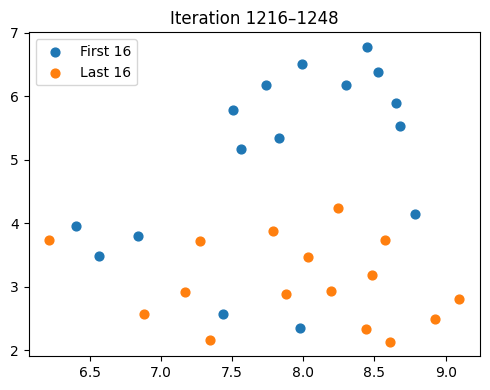

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


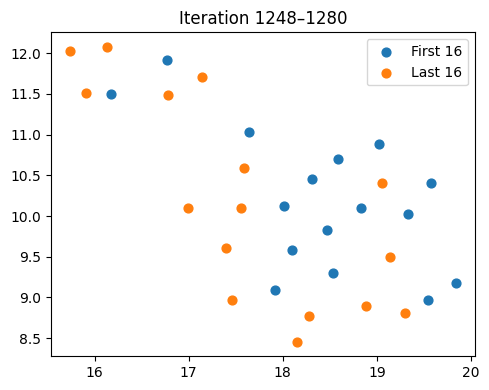

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


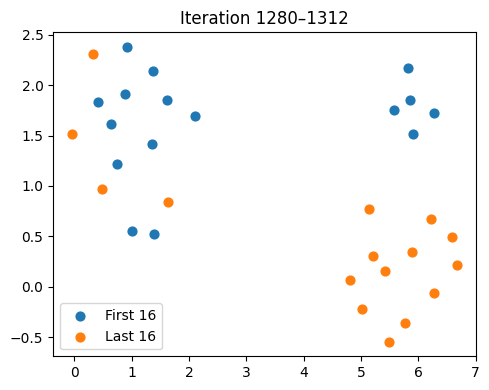

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


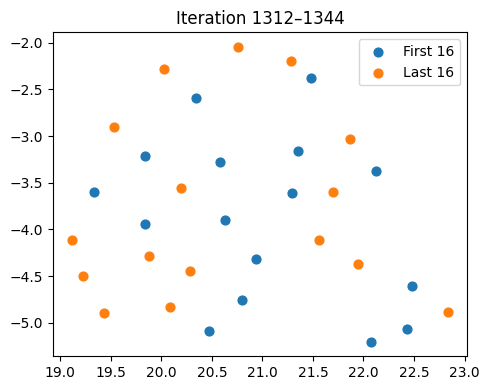

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


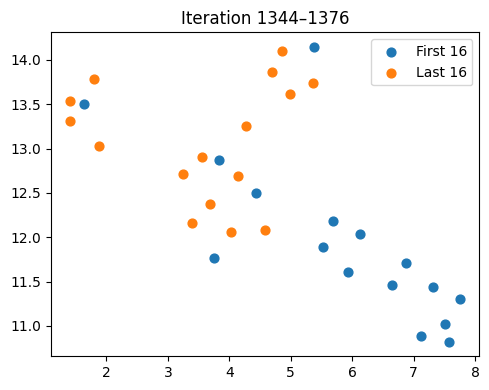

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


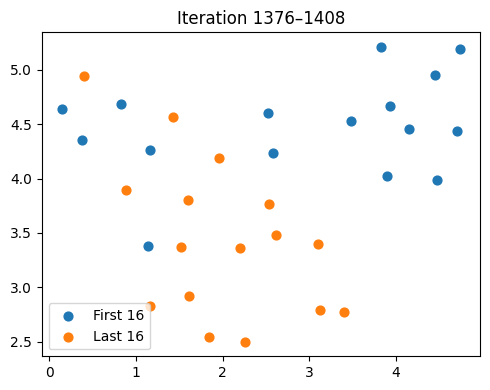

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


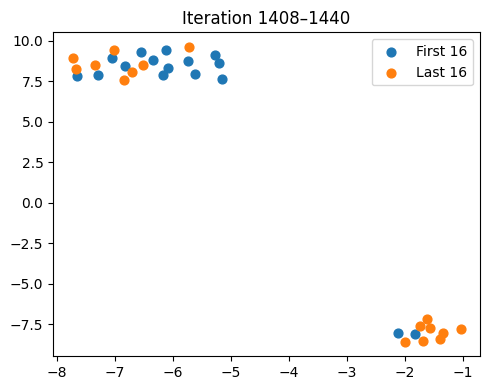

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


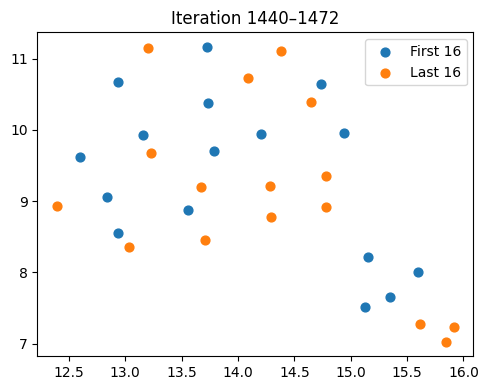

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


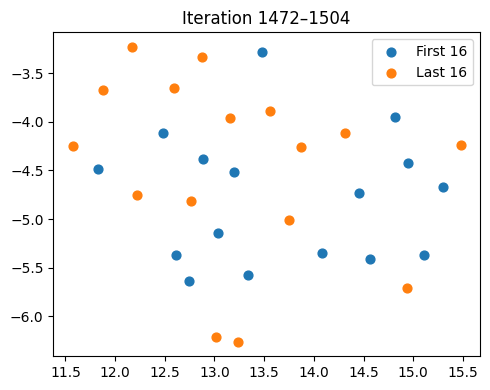

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


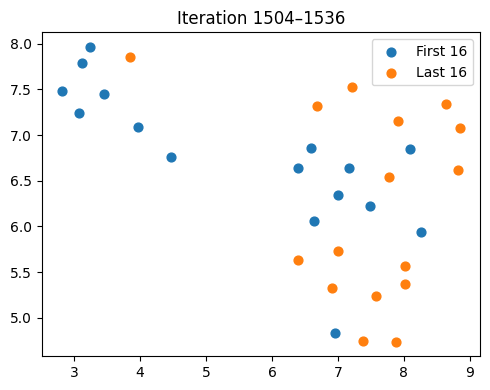

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


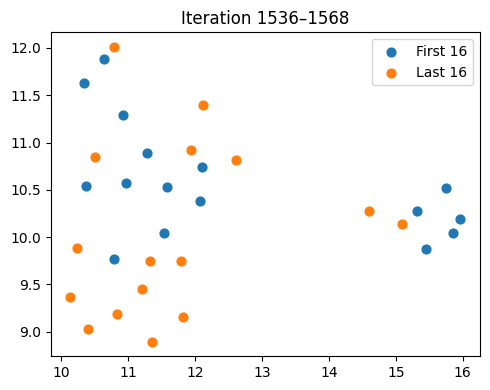

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


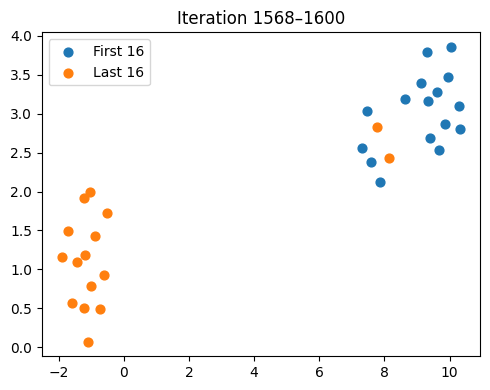

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


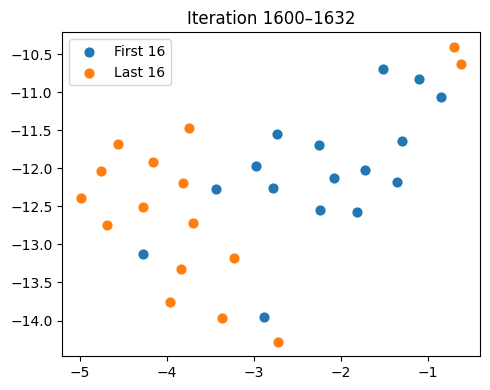

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


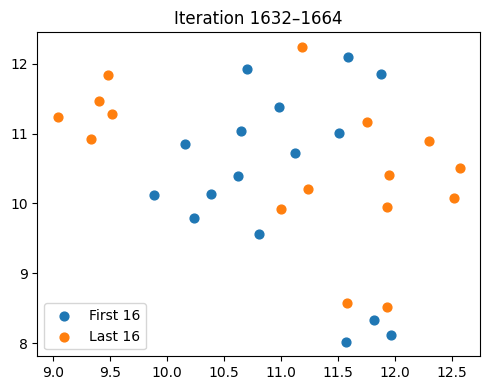

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


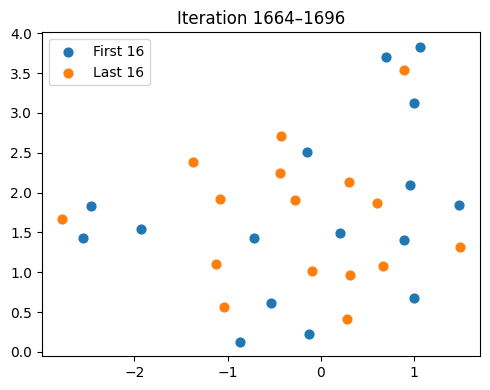

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


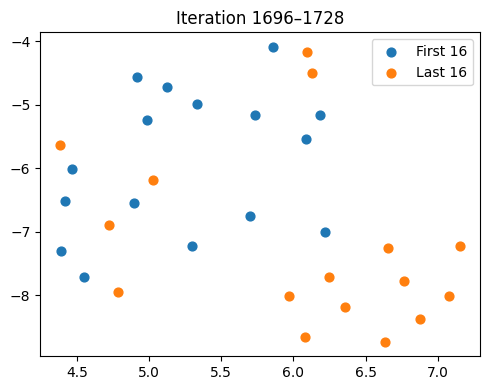

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


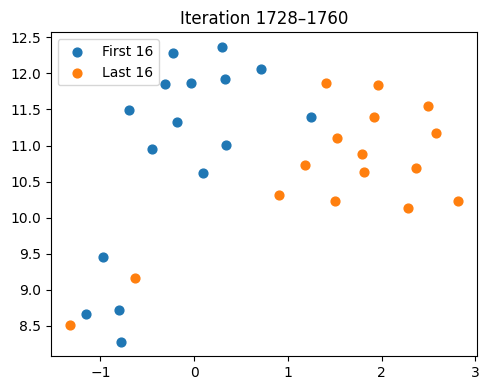

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


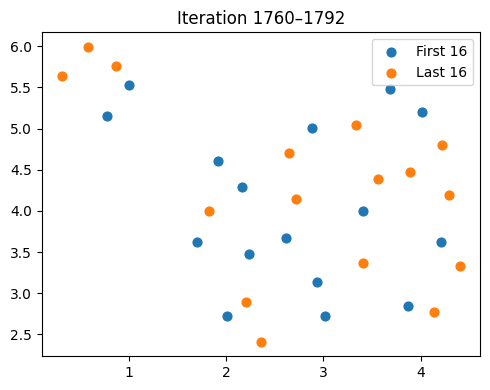

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


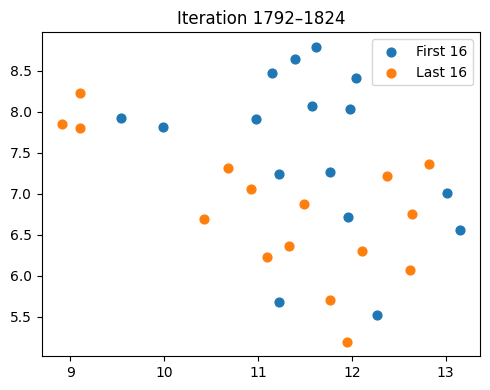

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


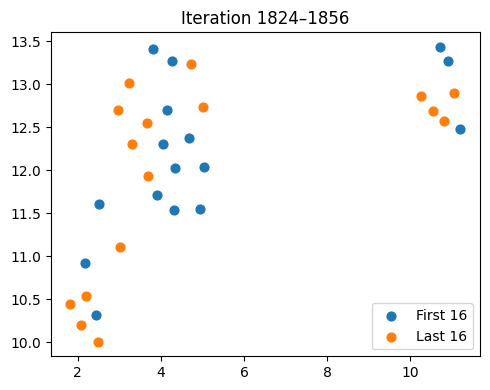

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


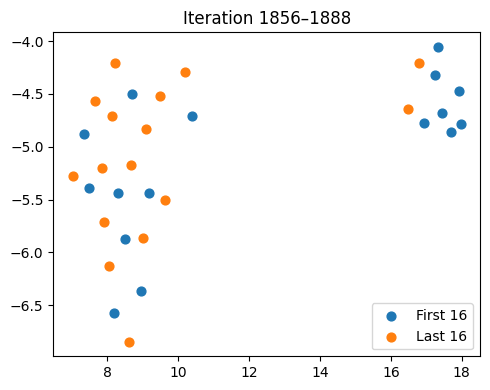

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


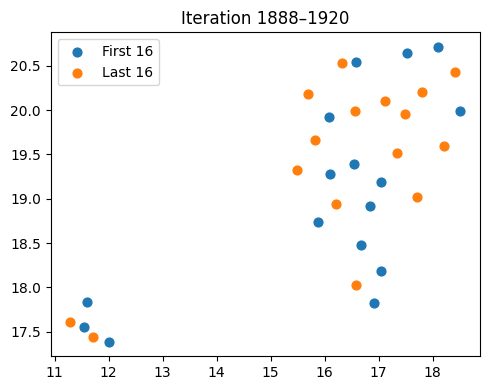

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


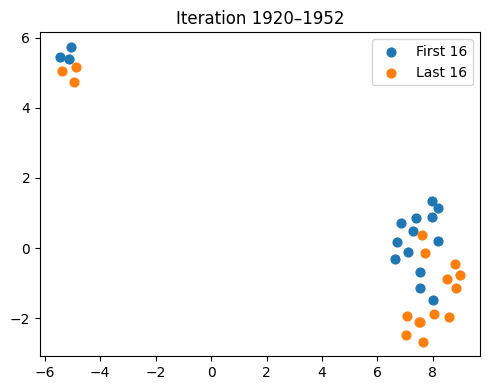

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


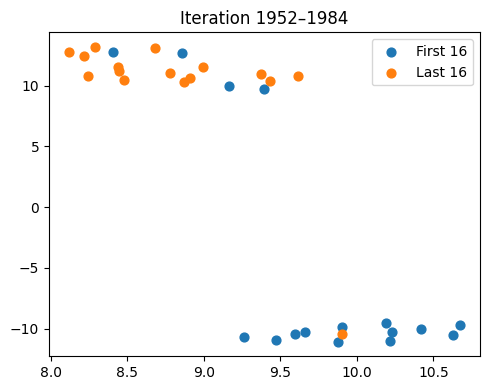

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


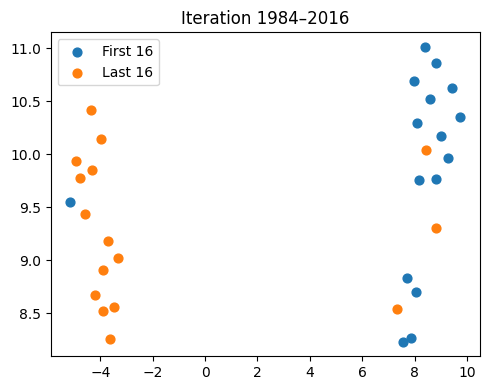

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


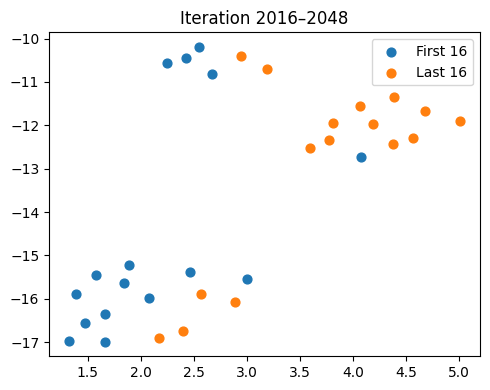

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


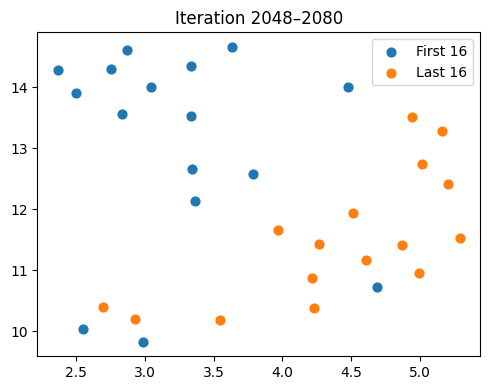

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


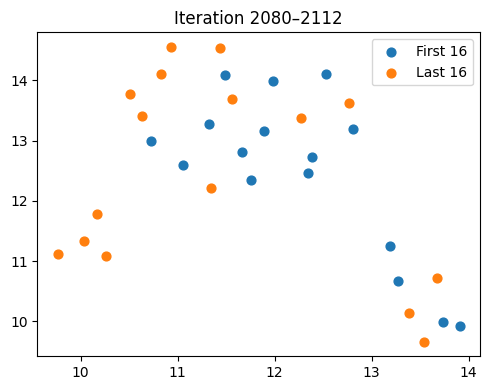

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


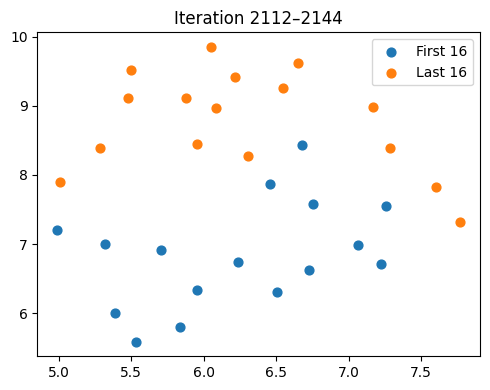

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


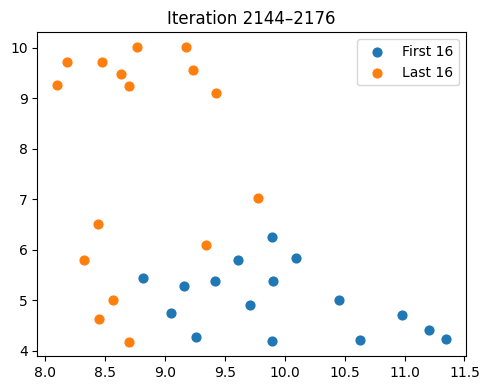

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


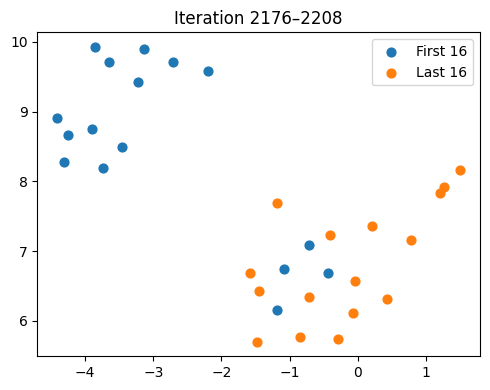

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


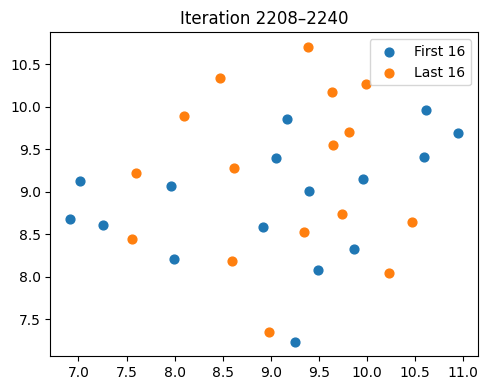

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


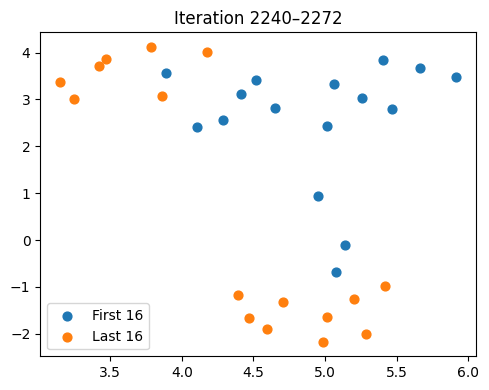

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


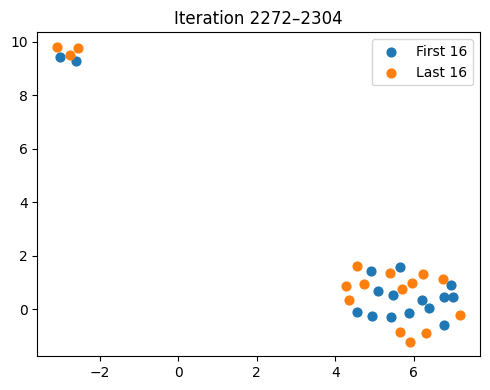

In [19]:
import umap
import matplotlib.pyplot as plt

block_size = 32
half = 16

for start in range(0, N - block_size + 1, block_size):
    
    end = start + block_size
    block = X[start:end]
    
    reducer = umap.UMAP(
        n_neighbors=10,
        min_dist=0.1,
        random_state=42
    )
    
    embedding = reducer.fit_transform(block)
    
    labels = np.array([0]*half + [1]*half)
    
    plt.figure(figsize=(5,4))
    
    plt.scatter(
        embedding[labels==0, 0],
        embedding[labels==0, 1],
        s=40,
        label="First 16"
    )
    
    plt.scatter(
        embedding[labels==1, 0],
        embedding[labels==1, 1],
        s=40,
        label="Last 16"
    )
    
    plt.title(f"Iteration {start}–{end}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import umap

start_idx = 0
end_idx = 2304
batch_size = 64

output_dir = "umap_progress"
os.makedirs(output_dir, exist_ok=True)

# 全部数据
X_all = X[start_idx:end_idx+1]
n_samples = X_all.shape[0]

# ---------- UMAP降维（只做一次） ----------
n_neighbors = min(20, n_samples - 1)

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_all)

print("UMAP降维完成")


for left in range(0, n_samples, batch_size):

    right = min(left + batch_size, n_samples)

    plt.figure(figsize=(8,6))

    # 1. 背景所有点（灰色）
    plt.scatter(
        embedding[:,0],
        embedding[:,1],
        s=50,
        c='lightgray',
        alpha=0.4
    )

    # 2. 历史点（蓝色）
    if left > 0:
        history_idx = np.arange(0, left)
        plt.scatter(
            embedding[history_idx,0],
            embedding[history_idx,1],
            s=25,
            c='blue',
            alpha=0.7,
            label="Previous samples"
        )

    # 3. 当前新采样点（红色）
    new_idx = np.arange(left, right)
    plt.scatter(
        embedding[new_idx,0],
        embedding[new_idx,1],
        s=35,
        c='red',
        alpha=0.9,
        label="New samples"
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    # plt.title(f"Sampling step {right}/{n_samples}")
    
				plt.set_xlabel("UMAP 1", fontsize=26)
				plt.set_ylabel("UMAP 2", fontsize=26)

				from matplotlib.ticker import AutoMinorLocator
				plt.minorticks_on()
				plt.xaxis.set_minor_locator(AutoMinorLocator(2))
				plt.yaxis.set_minor_locator(AutoMinorLocator(2))
				plt.tick_params(which='minor', length=4)

				plt.legend(fontsize=24, frameon=True, edgecolor='black',fancybox=False)
    

    plt.tight_layout()

    filename = f"sampling_{right:04d}.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=150)
    plt.close()

    print(f"保存: {filename}")

print("全部完成")

TabError: inconsistent use of tabs and spaces in indentation (367035536.py, line 73)

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import umap

start_idx = 0
end_idx = 2304
batch_size = 64

output_dir = "umap_progress"
os.makedirs(output_dir, exist_ok=True)

# 全部数据
X_all = X[start_idx:end_idx+1]
n_samples = X_all.shape[0]
n_neighbors = min(20, n_samples - 1)

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_all)
for left in range(0, n_samples, batch_size):
    right = min(left + batch_size, n_samples)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=50,
        c='lightgray',
        alpha=0.4,
								label="All sampled points"
    )
    if left > 0:
        history_idx = np.arange(0, left)
        ax.scatter(
            embedding[history_idx, 0],
            embedding[history_idx, 1],
            s=50,
            alpha=0.7,
            label="Pre-transition",
												color='#136AEE'
        )
    new_idx = np.arange(left, right)
    ax.scatter(
        embedding[new_idx, 0],
        embedding[new_idx, 1],
        s=50,
        alpha=0.9,
        label="Post-transition",
								color='#FF7F0E'
    )
    ax.set_xlabel("Dimension 1", fontsize=16, fontweight='bold')
    ax.set_ylabel("Dimension 2", fontsize=16, fontweight='bold')
    plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='minor', length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    fig.subplots_adjust(
        left=1.918/10.72,
        right=1 - (1.492/10.72),
        bottom=0.15,
        top=1 - (0.9517/8.205)
    )

    filename = f"sampling_{right:04d}.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=1200, transparent=True)
    plt.close()
    print(f"保存: {filename}")

print("全部完成")

/work/scratch/xt17pyku/miniconda3/envs/leed/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


保存: sampling_0064.png
保存: sampling_0128.png
保存: sampling_0192.png
保存: sampling_0256.png
保存: sampling_0320.png
保存: sampling_0384.png
保存: sampling_0448.png
保存: sampling_0512.png
保存: sampling_0576.png
保存: sampling_0640.png
保存: sampling_0704.png
保存: sampling_0768.png
保存: sampling_0832.png
保存: sampling_0896.png
保存: sampling_0960.png
保存: sampling_1024.png
保存: sampling_1088.png
保存: sampling_1152.png
保存: sampling_1216.png
保存: sampling_1280.png
保存: sampling_1344.png
保存: sampling_1408.png
保存: sampling_1472.png
保存: sampling_1536.png
保存: sampling_1600.png
保存: sampling_1664.png
保存: sampling_1728.png
保存: sampling_1792.png
保存: sampling_1856.png
保存: sampling_1920.png
保存: sampling_1984.png
保存: sampling_2048.png
保存: sampling_2112.png
保存: sampling_2176.png
保存: sampling_2240.png
保存: sampling_2304.png
保存: sampling_2305.png
全部完成
